In [1]:
# Generated from: mnist_mlp_training_and_export.ipynb
# Converted at: 2026-05-06T14:26:33.933Z
# Next step (optional): refactor into modules & generate tests with RunCell
# Quick start: pip install runcell

# Training an MLP (Multi-layer Perceptron) on MNIST for FPGA Deployment — NumPy from Scratch

**Model Architecture:**
- Input layer:  784 units (Flattened 28x28 MNIST images)
- Hidden layer: 128 units (Weights: W1 (784 x 128) | Bias: b1 (128) | Activation: *Leaky ReLU*)
- Output layer: 10 units  (Weights: W2 (128 x 10)  | Bias:          | Activation: *Softmax/Argmax*)

**Additional Details:**
- **Forward Propagation:** z1 = Input x W1 + b1 -> a1 = leaky ReLU(z1) -> z2 = a1 x W2 -> sigma = Softmax(z2)
- Weight initialization: *He initialization*
- Optimizer: *RMSprop*
- Loss function: Cross-entropy + L2 Regularization
- Softmax with *numerical stability*
- Model size reduction via *Quantization* from FP32 to INT8, exported as .hex files

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Load Data


Read the data

In [3]:
train_data = pd.read_csv("input/train.csv")
test_data  = pd.read_csv("input/test.csv")

# Set up the data
y_train = train_data['label'].values
X_train = train_data.drop(columns=['label']).values / 255.0
X_test  = test_data.values / 255.0

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"X_train: {X_train.dtype}, y_train: {y_train.dtype}")
print(f"X_test : {X_test.dtype}")

X_train: (42000, 784), y_train: (42000,)
X_test : (28000, 784)
X_train: float64, y_train: int64
X_test : float64


## 2. Sample Images from Training Set

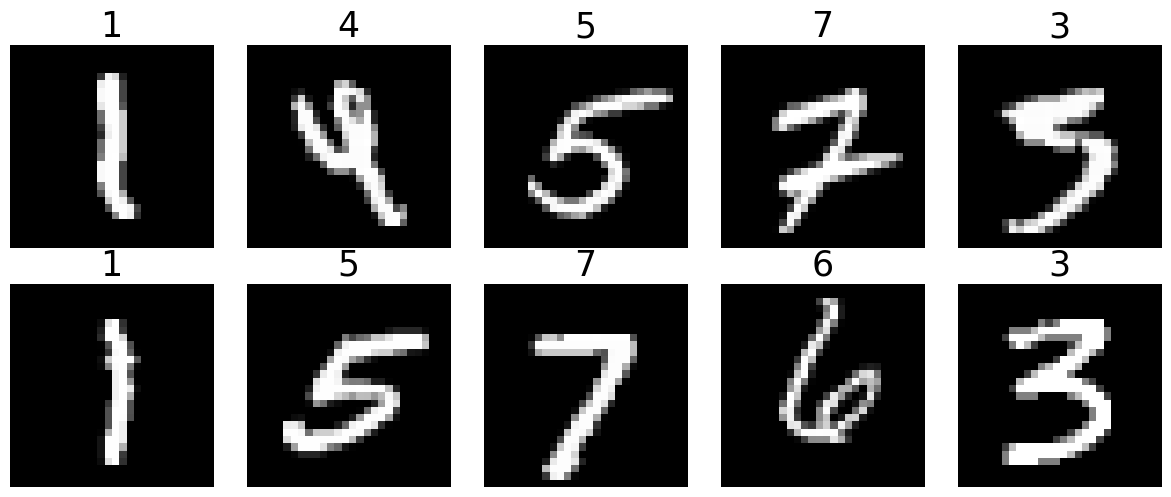

In [4]:
fig, axes = plt.subplots(2,5,figsize=(12,5))
axes = axes.flatten()
idx = np.random.randint(0,len(X_train),size=10)
for i in range(10):
    axes[i].imshow(X_train[idx[i],:].reshape(28,28), cmap='gray')
    axes[i].axis('off') # hide the axes ticks
    axes[i].set_title(str(int(y_train[idx[i]])), color= 'black', fontsize=25)
plt.tight_layout()
plt.show()

## 3. Leaky ReLU Activation Function

Unlike standard ReLU (which zeroes all negative values), **Leaky ReLU** retains a small fraction of negative values:
$$
f(z) = \begin{cases} z & \text{if } z \geq 0 \\\ \alpha z & \text{if } z < 0 \end{cases}
$$
where $\alpha = 0.125$. This prevents the **"dying ReLU"** problem — neurons stuck at 0 that never update.

> 📖 *Maas, A. L., Hannun, A. Y., & Ng, A. Y. (2013). Rectifier Nonlinearities Improve Neural Network Acoustic Models. **ICML 2013**.*

In [5]:
def leaky_relu(z, alpha=0.125):
    """
    Leaky ReLU activation function.
    - z     : array of any shape
    - alpha : leak coefficient, default 0.125
    Returns array of same shape as z.
    """
    return np.where(z >= 0, z, alpha * z)


def leaky_relu_grad(z, alpha=0.125):
    """
    Derivative of Leaky ReLU for backpropagation.
    Returns 1 if z >= 0, alpha if z < 0.
    """
    return np.where(z >= 0, 1.0, alpha)

## 4. Forward Pass — `predict` Function

Takes input images through 2 linear transformations with activations, returns probability distribution over 10 digits.

Numerically stable Softmax: subtract `max` before `exp` to prevent overflow:
$$
\sigma_k = \frac{e^{z_k - \max(z)}}{\sum_j e^{z_j - \max(z)}}
$$

> 📖 *Bishop, C. M. (2006). Pattern Recognition and Machine Learning.*

In [6]:
def predict(X, params):
    """
    Forward pass through 2-layer MLP.

    Args:
        X      : input, shape (N, 784)
        params : dict with 'W1' (784, n_H), 'W2' (n_H, 10), 'b1' (n_H,)

    Returns:
        sigma  : output probabilities, shape (N, 10)
        a1     : hidden activation, shape (N, n_H) — for backprop
        z1     : hidden pre-activation, shape (N, n_H) — for backprop
    """
    W1, W2, b1 = params['W1'], params['W2'], params['b1']

    # Layer 1: Input -> Hidden
    z1    = np.matmul(X, W1) + b1          # (N, n_H)
    a1    = leaky_relu(z1)                  # (N, n_H)

    # Layer 2: Hidden -> Output
    z2    = np.matmul(a1, W2)              # (N, 10)

    # Numerically stable Softmax
    exp_z2 = np.exp(z2 - np.max(z2, axis=1, keepdims=True))
    sigma  = exp_z2 / np.sum(exp_z2, axis=1, keepdims=True)  # (N, 10)

    return sigma, a1, z1

## 5. Loss Function — Cross-entropy + L2 Regularization

$$
L = -\frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{K} \mathbf{1}_{\{y^{(i)}=k\}} \log \sigma_k^{(i)}
+ \frac{\lambda}{2}\left(\|W^{(1)}\|^2 + \|W^{(2)}\|^2\right)
$$

> 📖 *Bishop, C. M. (2006). Pattern Recognition and Machine Learning, "using the cross-entropy error function instead of the sum-of-squares for a classification problem leads to faster training as well as improved generalization."*

In [7]:
def compute_loss(sigma, y_true, params, lam=1e-6):
    """
    Cross-entropy loss with L2 regularization.

    Args:
        sigma  : predicted probabilities, shape (N, 10)
        y_true : ground truth labels, shape (N,)
        params : weight dict (for regularization)
        lam    : L2 coefficient, default 1e-6

    Returns:
        loss   : float
    """
    N, K = len(y_true), 10
    y_one_hot     = (y_true[:, np.newaxis] == np.arange(K))         # (N, 10)
    cross_entropy = -np.mean(np.sum(np.log(sigma + 1e-8) * y_one_hot, axis=1))
    l2_reg        = (lam / 2) * (np.sum(params['W1']**2) + np.sum(params['W2']**2))
    return cross_entropy + l2_reg

## 6. Backpropagation — Gradient Computation

Apply chain rule backwards from output to input layer:

$$
\delta^{(2)} = \sigma - \mathbf{1}_{y}, \quad
\nabla_{W^{(2)}} = \frac{1}{N} a_1^\top \delta^{(2)}
$$
$$
\delta^{(1)} = \delta^{(2)} (W^{(2)})^\top \odot f'(z_1), \quad
\nabla_{W^{(1)}} = \frac{1}{N} X^\top \delta^{(1)}
$$

> 📖 Marsland, S. (2015). Machine Learning: An Algorithmic Perspective.

In [8]:
def backprop(X, y_true, params, lam=1e-6):
    """
    Compute gradients of loss w.r.t. all parameters.

    Args:
        X      : input, shape (N, 784)
        y_true : ground truth labels, shape (N,)
        params : current weight dict
        lam    : L2 regularization coefficient

    Returns:
        grads  : dict containing 'dW1', 'dW2', 'db1'
    """
    N, K = X.shape[0], 10
    W1, W2 = params['W1'], params['W2']

    # --- Forward pass (cache intermediates for backward) ---
    sigma, a1, z1 = predict(X, params)               # (N,10), (N,n_H), (N,n_H)

    # --- Backward pass ---
    y_one_hot = (y_true[:, np.newaxis] == np.arange(K))  # (N, 10)

    # Output layer gradient
    delta2 = sigma - y_one_hot                        # (N, 10)
    dW2    = np.matmul(a1.T, delta2) / N + lam * W2  # (n_H, 10)

    # Hidden layer gradient (backprop through Leaky ReLU)
    delta1 = np.matmul(delta2, W2.T) * leaky_relu_grad(z1)  # (N, n_H)
    dW1    = np.matmul(X.T, delta1) / N + lam * W1          # (784, n_H)
    db1    = np.mean(delta1, axis=0)                         # (n_H,)

    return {'dW1': dW1, 'dW2': dW2, 'db1': db1}

## 7. Hyperparameters and Weight Initialization

Using **He initialization**: $W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}}}}\right)$

Better suited for Leaky ReLU than standard random initialization.

> 📖 *He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving Deep into Rectifiers. **ICCV 2015**.*


Hyperparameters

In [9]:
eta      = 5e-1   # learning rate
lam      = 1e-6   # L2 regularization
gamma    = 0.99   # RMSprop decay
eps      = 1e-3   # RMSprop epsilon
num_iter = 1000   # gradient descent iterations
n_H      = 128    # hidden layer neurons
n        = X_train.shape[1]  # 784
K        = 10

# Weight initialization — He initialization
np.random.seed(2392004)

params = {
    'W1': np.random.randn(n,   n_H) * np.sqrt(2.0 / n),    # (784, 512)
    'W2': np.random.randn(n_H, K  ) * np.sqrt(2.0 / n_H),  # (512,  10)
    'b1': np.zeros(n_H)                                      # (512,)
}

print("Parameter sizes:")
for name, val in params.items():
    print(f"  {name}: {val.shape}")

Kích thước tham số:
  W1: (784, 128)
  W2: (128, 10)
  b1: (128,)


## 8. Training — RMSprop Gradient Descent

$$
g_t = \gamma \cdot g_{t-1} + (1 - \gamma) \cdot |\nabla W|^2, \quad
W \leftarrow W - \frac{\eta}{\sqrt{g_t + \epsilon}} \nabla W
$$

> 📖 *Tieleman, T. & Hinton, G. (2012). Lecture 6e: RMSProp. **COURSERA: Neural Networks for Machine Learning**. University of Toronto.*

In [10]:
%%time

# RMSprop cache — initialized to 1
gW1 = gW2 = gb1 = 1.0

loss_history = []
acc_history  = []

for i in range(num_iter):
    grads = backprop(X_train, y_train, params, lam)

    # --- RMSprop update ---
    gW1 = gamma * gW1 + (1 - gamma) * np.sum(grads['dW1']**2)
    etaW1 = eta / np.sqrt(gW1 + eps)
    params['W1'] -= etaW1 * grads['dW1']

    gW2 = gamma * gW2 + (1 - gamma) * np.sum(grads['dW2']**2)
    etaW2 = eta / np.sqrt(gW2 + eps)
    params['W2'] -= etaW2 * grads['dW2']

    gb1 = gamma * gb1 + (1 - gamma) * np.sum(grads['db1']**2)
    etab1 = eta / np.sqrt(gb1 + eps)
    params['b1'] -= etab1 * grads['db1']

    # --- Log every 50 iterations ---
    if i % 50 == 0:
        sigma, _, _ = predict(X_train, params)
        current_loss = compute_loss(sigma, y_train, params, lam)
        current_acc  = np.mean(np.argmax(sigma, axis=1) == y_train)

        loss_history.append(current_loss)
        acc_history.append(current_acc)

        print(f"Cross-entropy loss after {i+1} iterations is {current_loss:.7f}")
        print(f"Training accuracy after {i+1} iterations is {current_acc:.4%}")
        print(f"gW1={gW1:.4f} gW2={gW2:.4f} gb1={gb1:.4f}")
        print(f"etaW1={etaW1:.4f} etaW2={etaW2:.4f} etab1={etab1:.4f}")
        print(f"|dW1|={np.linalg.norm(grads['dW1']):.5f} "
              f"|dW2|={np.linalg.norm(grads['dW2']):.5f} "
              f"|db1|={np.linalg.norm(grads['db1']):.5f}", "\n")

        # Reset RMSprop cache
        gW1 = gW2 = gb1 = 1.0

# --- Final results ---
sigma_final, _, _ = predict(X_train, params)
final_loss = compute_loss(sigma_final, y_train, params, lam)
final_acc  = np.mean(np.argmax(sigma_final, axis=1) == y_train)
print(f"Final cross-entropy loss is {final_loss:.7f}")
print(f"Final training accuracy is {final_acc:.4%}")

Cross-entropy loss after 1 iterations is 1.9016589
Training accuracy after 1 iterations is 41.7476%
gW1=1.0041 gW2=0.9921 gb1=0.9901
etaW1=0.4987 etaW2=0.5017 etab1=0.5022
|dW1|=1.18598 |dW2|=0.45896 |db1|=0.11375 

Cross-entropy loss after 51 iterations is 0.3397802
Training accuracy after 51 iterations is 90.3381%
gW1=0.8111 gW2=0.6843 gb1=0.6095
etaW1=0.5549 etaW2=0.6040 etab1=0.6399
|dW1|=0.16426 |dW2|=0.12736 |db1|=0.02873 

Cross-entropy loss after 101 iterations is 0.2938490
Training accuracy after 101 iterations is 91.3619%
gW1=0.6287 gW2=0.6197 gb1=0.6056
etaW1=0.6301 etaW2=0.6346 etab1=0.6420
|dW1|=0.31174 |dW2|=0.24580 |db1|=0.05128 

Cross-entropy loss after 151 iterations is 0.2231564
Training accuracy after 151 iterations is 93.6857%
gW1=0.6069 gW2=0.6060 gb1=0.6050
etaW1=0.6413 etaW2=0.6418 etab1=0.6423
|dW1|=0.02856 |dW2|=0.01795 |db1|=0.00274 

Cross-entropy loss after 201 iterations is 0.1963111
Training accuracy after 201 iterations is 94.4786%
gW1=0.6053 gW2=0.6051 

## 9. Training Visualization

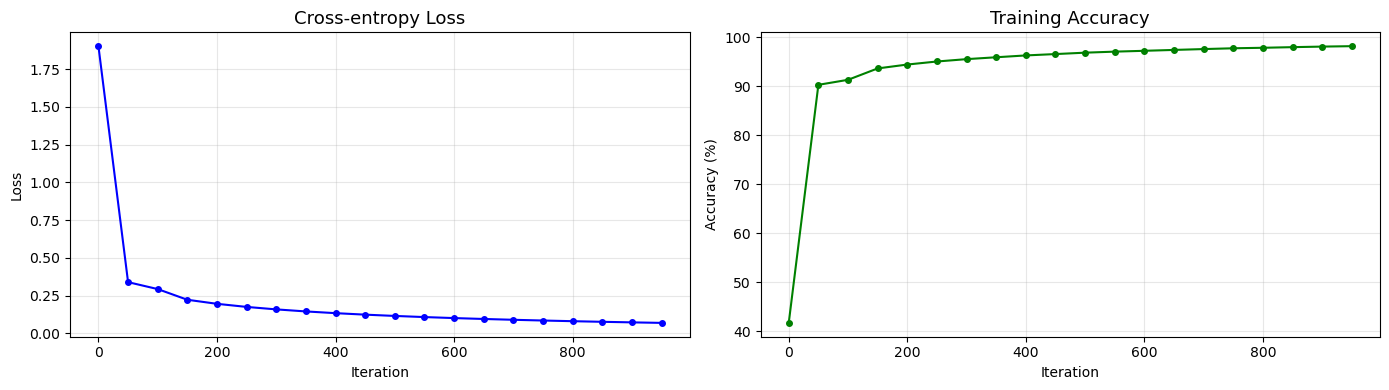

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(range(0, num_iter, 50), loss_history, 'b-o', markersize=4)
ax1.set_title("Cross-entropy Loss", fontsize=13)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(range(0, num_iter, 50), [a*100 for a in acc_history], 'g-o', markersize=4)
ax2.set_title("Training Accuracy", fontsize=13)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Accuracy (%)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Prediction and Export Results


Predict labels for test set

In [12]:
sigma_test, _, _ = predict(X_test, params)
y_pred_test = np.argmax(sigma_test, axis=1)

# Export submission submission
submission = pd.DataFrame({
    'ImageId': range(1, len(X_test) + 1),
    'Label'  : y_pred_test
})
submission.to_csv("my_mnist_result.csv", index=False)
print(f"Saved {len(submission)} predictions to my_mnist_result.csv")

Đã lưu 28000 dự đoán vào my_mnist_result.csv


## 11. Test Set Prediction Visualization


Select 10 random images from the test set and display predictions

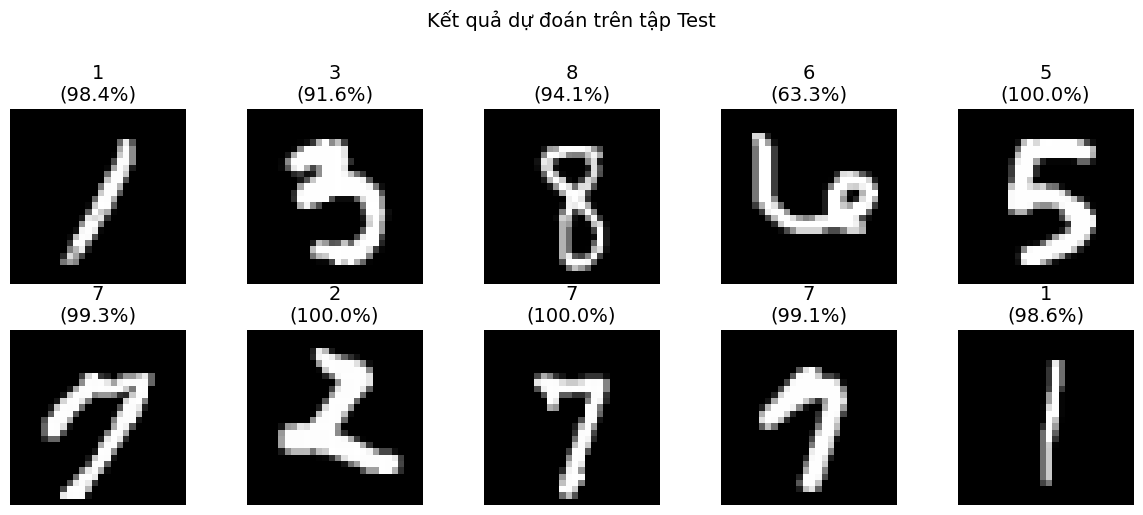

W1:
  - Kiểu dữ liệu (dtype): float64
  - Kích thước (shape): (784, 128)
  - Dải giá trị (min, max): (-0.40339, 0.30243)
W2:
  - Kiểu dữ liệu (dtype): float64
  - Kích thước (shape): (128, 10)
  - Dải giá trị (min, max): (-0.99018, 0.98677)
b1:
  - Kiểu dữ liệu (dtype): float64
  - Kích thước (shape): (128,)
  - Dải giá trị (min, max): (-0.11652, 0.19870)
X_test:
  - Kiểu dữ liệu (dtype): float64
  - Kích thước (shape): (28000, 784)
  - Dải giá trị (min, max): (0.00000, 1.00000)


In [13]:
idx_test = np.random.randint(0, len(X_test), size=10)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img        = X_test[idx_test[i]].reshape(28, 28)
    pred_label = y_pred_test[idx_test[i]]
    confidence = sigma_test[idx_test[i], pred_label] * 100  # prediction confidence

    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(
        f"{pred_label}\n({confidence:.1f}%)",
        fontsize=14,
        color='black'
    )

plt.suptitle("Test Set Predictions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Check data types of trained parameters before quantization
for name, val in params.items():
    print(f"{name}:")
    print(f"  - dtype: {val.dtype}")
    print(f"  - shape: {val.shape}")
    print(f"  - range (min, max): ({np.min(val):.5f}, {np.max(val):.5f})")

print(f"X_test:")
print(f"  - dtype: {X_test.dtype}")
print(f"  - shape: {X_test.shape}")
print(f"  - range (min, max): ({np.min(X_test):.5f}, {np.max(X_test):.5f})")

## 12. Post-Training Quantization

Using **Symmetric Quantization**: W1 and W2 from **FP64** to **INT8**

Scale computation:
$$
\text{scale} = \frac{2^{8-1} - 1}{\max(|x|)}
$$

Quantization formula:

$$
x_{\text{quantize}} = \text{clip}\left(
\text{round}(x \cdot scale),
-2^{8-1} + 1,
2^{8-1} - 1
\right)
$$

In [14]:
def quantize_to_int8_symmetric(x):
    """
    Symmetric quantization from FP64 to INT8.

    Args:
        x : numpy array (float64 or float32)

    Returns:
        x_q    : int8 tensor
        scale  : scale factor (float)
    """

    # Find max absolute value
    max_val = np.max(np.abs(x))

    # If all zeros, return zero array with scale = 1.0
    if max_val == 0:
        return np.zeros_like(weights, dtype=np.int8), 1.0

    # Compute scale
    scale = max_val / 127.0  # (2 ** (8 - 1)) - 1

    # Quantize
    x_q = np.clip(np.round(x / scale), -127, 127).astype(np.int8)

    return x_q, scale

def quantize_bias_int32(b1, scale_X, scale_W):
    """
    Quantize bias from FP64 to INT32.
    
    Args:
        b1        : bias float64
        scale_X   : scale input
        scale_W   : scale weight
        
    Returns:
        b1_q       : bias int32
        scale_b1   : scale bias
    """
    # Compute scale
    scale_b1 = scale_X * scale_W
    
    # Quantize and round to nearest integer
    b1_q = np.round(b1 / scale_b1) .astype(np.int32)
    
    return b1_q, scale_b1

scale_X = 1.0 / 127.0
W1_q, scale_W1 = quantize_to_int8_symmetric(params['W1'])
W2_q, scale_W2 = quantize_to_int8_symmetric(params['W2'])
b1_q, scale_b1 = quantize_bias_int32(params['b1'], scale_X, scale_W1)
X_q = np.clip(np.round(X_test / scale_X), 0, 127).astype(np.int8)

print(f"W1 Quantize:")
print(f"  - Scale: {scale_W1:.8f}")
print(f"  - dtype: {W1_q.dtype}")
print(f"  - shape: {W1_q.shape}")
print(f"  - range (min, max): ({W1_q.min()}, {W1_q.max()})")

print(f"W2 Quantize:")
print(f"  - Scale: {scale_W2:.8f}")
print(f"  - dtype: {W2_q.dtype}")
print(f"  - shape: {W2_q.shape}")
print(f"  - range (min, max): ({W2_q.min()}, {W2_q.max()})")

print(f"b1 Quantize:")
print(f"  - Scale: {scale_b1:.8f}")
print(f"  - dtype: {b1_q.dtype}")
print(f"  - shape: {b1_q.shape}")
print(f"  - range (min, max): ({b1_q.min()}, {b1_q.max()})")

print(f"X Quantize:")
print(f"  - Scale: {scale_X:.8f}")
print(f"  - dtype: {X_q.dtype}")
print(f"  - shape: {X_q.shape}")
print(f"  - range (min, max): ({X_q.min()}, {X_q.max()})")

W1 Quantize:
  - Scale: 0.00317628
  - Kiểu dữ liệu (dtype): int8
  - Kích thước (shape): (784, 128)
  - Dải giá trị (min, max): (-127, 95)
W2 Quantize:
  - Scale: 0.00779668
  - Kiểu dữ liệu (dtype): int8
  - Kích thước (shape): (128, 10)
  - Dải giá trị (min, max): (-127, 127)
b1 Quantize:
  - Scale: 0.00002501
  - Kiểu dữ liệu (dtype): int32
  - Kích thước (shape): (128,)
  - Dải giá trị (min, max): (-4659, 7945)
X Quantize:
  - Scale: 0.00787402
  - Kiểu dữ liệu (dtype): int8
  - Kích thước (shape): (28000, 784)
  - Dải giá trị (min, max): (0, 127)


## 13. Hardware Requantization Parameters

In Python, after integer MAC operations, we typically **dequantize to float** to apply activation functions:

$$
z_1 = z_{1,\text{int32}} \cdot (scale_X \cdot scale_{W1})
$$

However, on FPGA hardware, **floating-point is too expensive**. We replace float multiplication with integer-only operations.

**Key Idea**

Approximate the scale factor using integers:

$$
\text{scale} \;\approx\; \frac{\text{MULT}}{2^{\text{SHIFT}}}
$$

The computation becomes:

$$
z_1 \approx \left( z_{1,\text{int32}} \cdot \text{MULT} \right) \gg \text{SHIFT}
$$

**Purpose of MULT and SHIFT**

- Replace float multiplication with integer operations on hardware  
- Perform **inter-layer scale conversion**  
- Enable fully integer inference process (INT8/INT32)  

**MULT and SHIFT Formula**

To ensure correct inter-layer scaling:

$$
\frac{\text{MULT}}{2^{\text{SHIFT}}}
\;\approx\;
\frac{scale_{\text{input}} \cdot scale_{\text{weight}}}{scale_{\text{output}}}
$$

**Summary**

Using MULT and SHIFT enables:
- Completely eliminate floating-point operations  
- Optimize performance and resources on FPGA  
- Ensure consistency between Python simulation and hardware execution 


Calculate hidden scale

In [15]:
W1, W2, b1 = params['W1'], params['W2'], params['b1']
z1 = np.matmul(X_test, W1) + b1
a1 = leaky_relu(z1)  

max_val = np.max(np.abs(a1))
hidden_scale = max_val / 127.0

if max_val == 0:
        hidden_scale = 1.0

print(f"hidden_scale: {hidden_scale:.8f}")

def compute_requant_params(input_scale, weight_scale, output_scale, shift_bits=15):
    ratio = (input_scale * weight_scale) / output_scale
    mult = int(round(ratio * (2 ** shift_bits)))
    mult = max(-32768, min(32767, mult))
    return mult, shift_bits

MULT_L1, SHIFT_L1 = compute_requant_params(scale_X, scale_W1, hidden_scale)

print("MULT_L1:", MULT_L1)
print("SHIFT_L1:", SHIFT_L1)

hidden_scale: 0.06903499
MULT_L1: 12
SHIFT_L1: 15


## 14. Validation of Quantized Training Results

Đã lưu 28000 dự đoán INT8 vào my_mnist_result_int8.csv


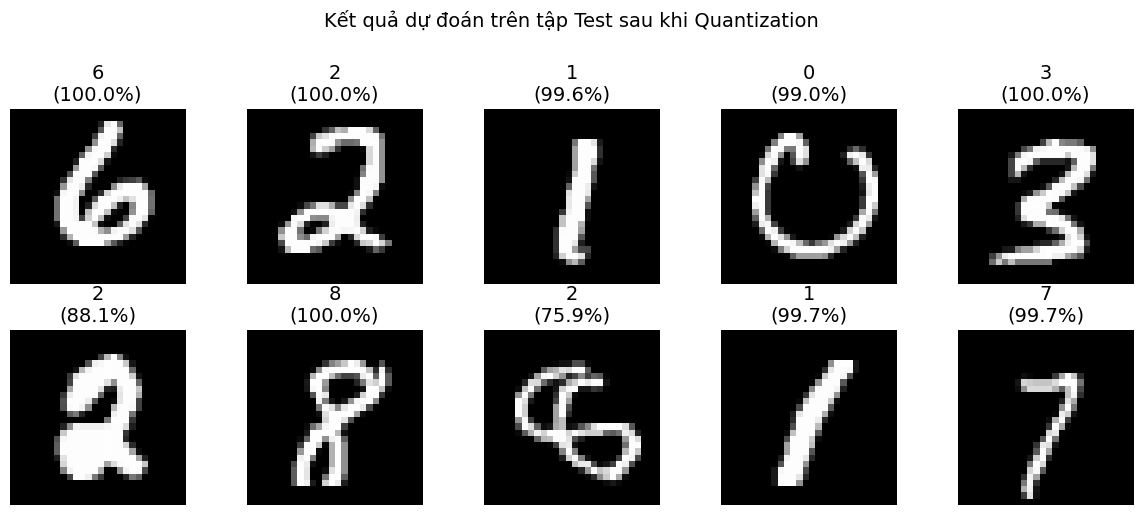

FP32 Accuracy    : 1.0000
INT8 Accuracy    : 0.9977
Drop             : 0.0023
INT8 vs HW match : 0.9955


In [19]:
def predict_int8(X_q, W1_q, W2_q, b1_q, scale_X, scale_W1, scale_W2):
    """
    INT8 inference with dequantization (validation).
    """

    # --- Layer 1: INT32 MAC ---
    z1_int32 = np.matmul(X_q.astype(np.int32), W1_q.astype(np.int32)) + b1_q

    # --- Dequantize to float for activation ---
    z1 = z1_int32 * (scale_X * scale_W1)

    # --- Leaky ReLU ---
    a1 = np.where(z1 >= 0, z1, 0.125 * z1)

    # --- Re-quantize activation ---
    max_a1 = np.max(np.abs(a1))
    if max_a1 == 0:
        scale_a1 = 1.0
    else:
        scale_a1 = max_a1 / 127.0

    a1_q = np.round(a1 / scale_a1)
    a1_q = np.clip(a1_q, -127, 127).astype(np.int8)

    # --- Layer 2 ---
    z2_int32 = np.matmul(a1_q.astype(np.int32), W2_q.astype(np.int32))

    z2 = z2_int32 * (scale_a1 * scale_W2)

    # --- Softmax ---
    exp_z2 = np.exp(z2 - np.max(z2, axis=1, keepdims=True))
    sigma = exp_z2 / np.sum(exp_z2, axis=1, keepdims=True)

    return sigma

def predict_int8_hw(X_q, W1_q, W2_q, b1_q, MULT_L1, SHIFT_L1):
    """
    Hardware-accurate INT8 inference simulation.
    """

    # --- Layer 1 ---
    z1_int32 = np.matmul(X_q.astype(np.int32), W1_q.astype(np.int32)) + b1_q

    # --- Requant ---
    z1_scaled = np.clip((z1_int32.astype(np.int64) * MULT_L1) >> SHIFT_L1, -127, 127)

    # --- Leaky ReLU ---
    a1_int8 = np.where(z1_scaled >= 0, z1_scaled, z1_scaled >> 3).astype(np.int8)

    # --- Layer 2 ---
    z2_int32 = np.matmul(a1_int8.astype(np.int32), W2_q.astype(np.int32))

    # --- Argmax ---
    y_pred = np.argmax(z2_int32, axis=1)

    return y_pred

sigma_test_int8 = predict_int8(X_q, W1_q, W2_q, b1_q, scale_X, scale_W1, scale_W2)
y_pred_test_int8 = np.argmax(sigma_test_int8, axis=1)
y_pred_test_int8_hw = predict_int8_hw(X_q, W1_q, W2_q, b1_q, MULT_L1, SHIFT_L1)

# Export submission
submission = pd.DataFrame({
    'ImageId': range(1, len(X_q) + 1),
    'Label'  : y_pred_test_int8
})

submission.to_csv("my_mnist_result_int8.csv", index=False)
print(f"Saved {len(submission)} INT8 predictions to my_mnist_result_int8.csv")

idx_test = np.random.randint(0, len(X_q), size=10)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img        = X_test[idx_test[i]].reshape(28, 28)
    pred_label = y_pred_test_int8[idx_test[i]]
    confidence = sigma_test_int8[idx_test[i], pred_label] * 100

    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(
        f"{pred_label}\n({confidence:.1f}%)",
        fontsize=14
    )

plt.suptitle("Test Set Predictions (INT8 Quantized)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Compare FP32 vs INT8 quantized model
acc_float = np.mean(y_pred_test == y_pred_test) # would be more accurate if compared to y_test
acc_int8  = np.mean(y_pred_test_int8 == y_pred_test)
match_hw  = np.mean(y_pred_test_int8 == y_pred_test_int8_hw)

print(f"FP32 Accuracy    : {acc_float:.4f}")
print(f"INT8 Accuracy    : {acc_int8:.4f}")
print(f"Drop             : {acc_float - acc_int8:.4f}")
print(f"INT8 vs HW match : {match_hw:.4f}")

## 15. Export MNIST Images to .h File

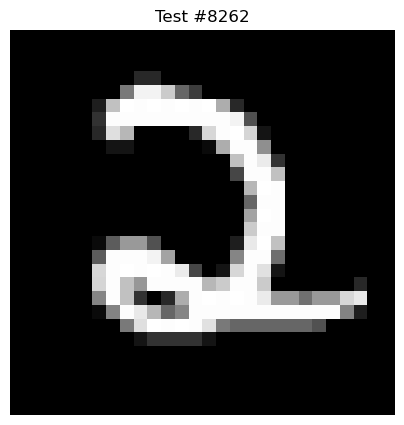

  ✓ Exported test_image.h (784 values)


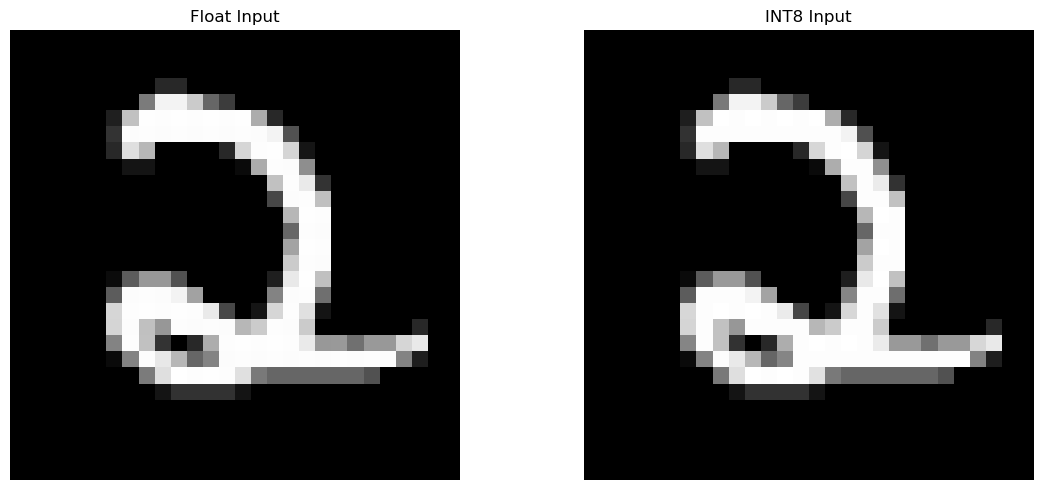

RESULT COMPARISON
FP32 Prediction      : 2
INT8 HW Prediction   : [2]


In [17]:
def export_image_to_header(img, filename, var_name):
    """
    Export INT8 image as C header array.
    
    Args:
        img: numpy array (784,) int8
        filename: output .h file path
        var_name: C variable name
    """
    img = img.flatten()

    with open(filename, "w") as f:
        f.write(f"#ifndef {var_name.upper()}_H\n")
        f.write(f"#define {var_name.upper()}_H\n\n")

        f.write("#include <stdint.h>\n\n")

        f.write(f"const int8_t {var_name}[{len(img)}] = {{\n")

        for i, val in enumerate(img):
            if i % 16 == 0:
                f.write("    ")

            f.write(f"{int(val)}")

            if i != len(img) - 1:
                f.write(", ")

            if (i + 1) % 16 == 0:
                f.write("\n")

        f.write("\n};\n\n")
        f.write(f"#endif // {var_name.upper()}_H\n")

    print(f"  ✓ Exported {filename} ({len(img)} values)")

# Select a random test image
idx = np.random.randint(0, len(X_test))
img = X_q[idx]

plt.figure(figsize=(12, 5))
plt.imshow(img.reshape(28,28), cmap='gray')
plt.title(f"Test #{idx}")
plt.axis('off')
plt.show()

export_image_to_header(img, "test_image.h", "test_image")

# ===== Compare FP32 vs INT8 Hardware =====

# Get image before and after quantization
img_float = X_test[idx]   # float [0,1]
img_q     = X_q[idx]      # int8  [0,127]

# Display images
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.imshow(img_float.reshape(28,28), cmap='gray')
plt.title("Float Input")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_q.reshape(28,28), cmap='gray')
plt.title("INT8 Input")
plt.axis('off')

plt.tight_layout()
plt.show()

# ===== 4. Predict FP32 =====
sigma, _, _ = predict(img_float.reshape(1, -1), params)
y_pred_fp32 = np.argmax(sigma)

# ===== 5. Predict Hardware =====
y_pred_hw = predict_int8_hw(
    img_q.reshape(1, -1),
    W1_q, W2_q, b1_q,
    MULT_L1, SHIFT_L1
)

# ===== Print results =====
print("="*50)
print("RESULT COMPARISON")
print("="*50)

print(f"FP32 Prediction      : {y_pred_fp32}")
print(f"INT8 HW Prediction   : {y_pred_hw}")

## 16. Export Weights for FPGA (HEX Format)

Export Weights for FPGA — From Training Notebook to Verilog

**Purpose**
Notebook training xuat cac file `.hex` (w1_int8.hex, w2_int8.hex, b1_int32.hex, test_image.hex) voi layout **row-major**.
Tuy nhien, FSM trong Verilog doc weights theo **neuron-major** (column-major).

Notebook nay se:
1. Doc cac file `.hex` tu notebook training
2. **Transpose** weights sang neuron-major layout
3. Xuat file `.hex` tuong thich voi Verilog `$readmemh()`
4. Verify ket qua bang hardware-accurate inference simulation

**Tai sao can Transpose?**

```
Notebook training:  W1 shape = (784, 128)
                    W1[i, j] = weight tu input i den neuron j
                    flatten() -> row-major: W1[0,0], W1[0,1], ..., W1[0,127], W1[1,0], ...

Verilog FSM:        Doc tuan tu cho moi neuron:
                    Neuron 0: W1_ROM[0], W1_ROM[1], ..., W1_ROM[783]
                    Neuron 1: W1_ROM[784], ..., W1_ROM[1567]
                    => Can: W1[0,0], W1[1,0], ..., W1[783,0], W1[0,1], ... (column-major)

=> Phai TRANSPOSE truoc khi flatten!
```

**Verilog Parameters**
- `L1_REQUANT_MULT  = 12`
- `L1_REQUANT_SHIFT = 15`
- `LEAKY_SHIFT      = 3`   (Leaky ReLU alpha = 1/8 = 0.125)
- Activation: **Leaky ReLU**

✓ Exported image to test_image.hex


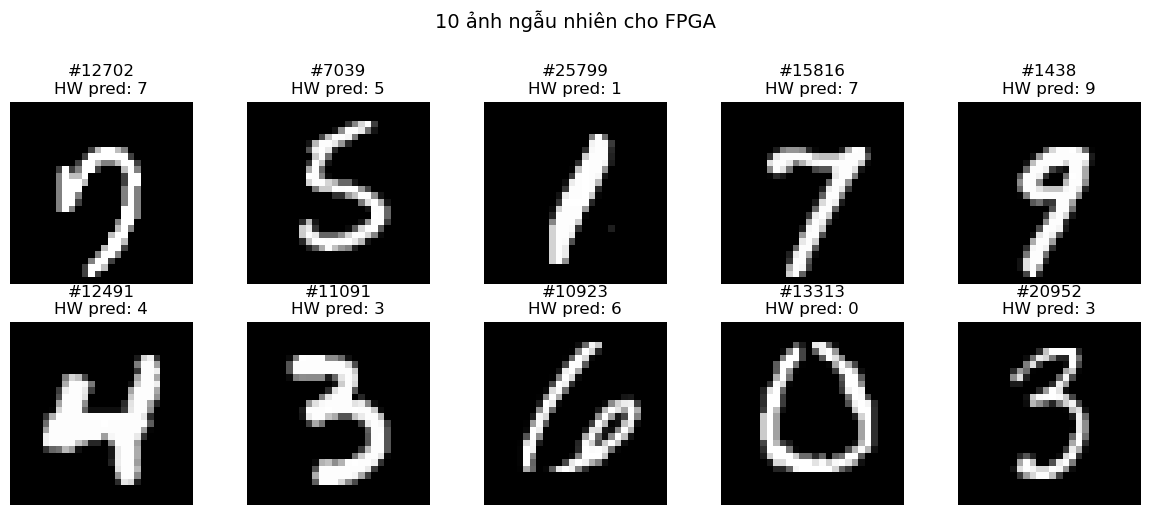

<Figure size 640x480 with 0 Axes>

  ✓ Exported test_image.h (10 images, 784 values each)


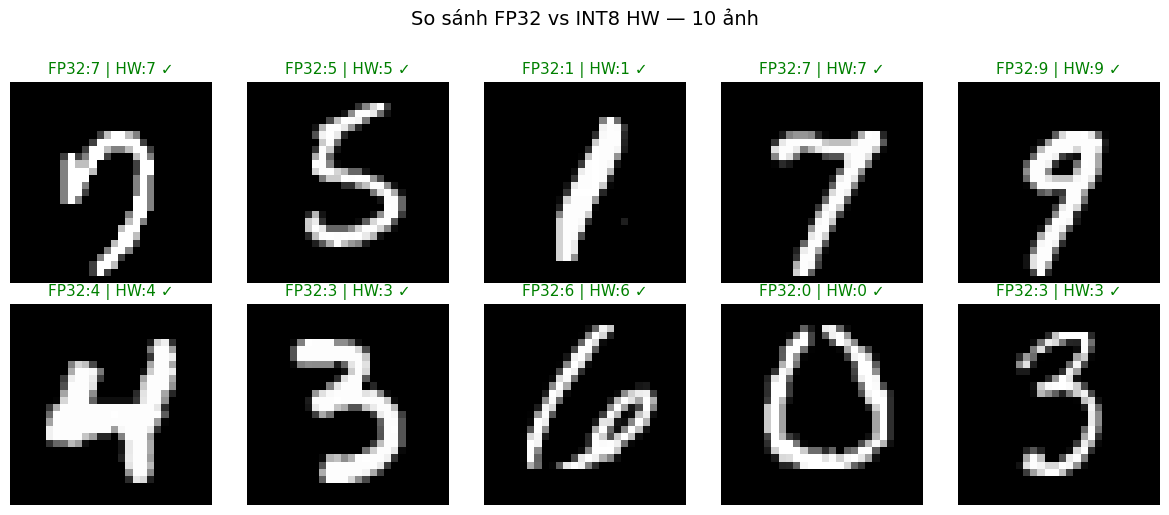

RESULT COMPARISON — 10 IMAGES
Image    Index    FP32     HW       Match   
--------------------------------------------------
0        12702    7        7        ✓       
1        7039     5        5        ✓       
2        25799    1        1        ✓       
3        15816    7        7        ✓       
4        1438     9        9        ✓       
5        12491    4        4        ✓       
6        11091    3        3        ✓       
7        10923    6        6        ✓       
8        13313    0        0        ✓       
9        20952    3        3        ✓       
--------------------------------------------------
FP32 vs HW match: 10/10 (100%)


In [18]:
def export_hex(data, filepath, name, width):
    """
    Xuat 1D numpy array thanh file .hex tuong thich voi Verilog $readmemh().
    Moi dong la 1 gia tri hex: 2 ky tu cho 8-bit, 8 ky tu cho 32-bit.
    """
    with open(filepath, 'w') as f:
        f.write(f'// {name}\n')
        f.write(f'// Total values: {len(data)}\n')
        for val in data:
            v = int(val)
            if width == 8:
                f.write(f'{v & 0xFF:02X}\n')
            elif width == 32:
                f.write(f'{v & 0xFFFFFFFF:08X}\n')

MULT_L1  = 12
SHIFT_L1 = 15
LEAKY_SHIFT = 3

W1_hw = W1_q.T   # (784,128) -> (128,784)
W2_hw = W2_q.T   # (128,10)  -> (10,128)

export_hex(W1_hw.flatten(), "w1_int8.hex", "W1", 8)
export_hex(W2_hw.flatten(), "w2_int8.hex", "W2", 8)
export_hex(b1_q,            "b1_int32.hex", "b1", 32)

def export_image_to_hex(img, filepath):
    """
    Export INT8 image (784 values) to .hex file for Verilog $readmemh().
    One value per line (2 hex digits).
    """
    img = img.flatten()

    with open(filepath, 'w') as f:
        f.write(f'// MNIST test image\n')
        f.write(f'// Total pixels: {len(img)}\n')

        for val in img:
            v = int(val) & 0xFF   # ensure unsigned hex format
            f.write(f'{v:02X}\n')

    print(f"✓ Exported image to {filepath}")
    
# ===== Export HEX =====
export_image_to_hex(img_q, "test_image.hex")

# Select 10 random test images
idx_test_10 = np.random.randint(0, len(X_q), size=10)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img = X_q[idx_test_10[i]].reshape(28, 28)
    pred = y_pred_test_int8_hw[idx_test_10[i]]
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"#{idx_test_10[i]}\nHW pred: {pred}", fontsize=12)

plt.suptitle("10 Random Test Images for FPGA", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


for i in range(10):
    img        = X_test[idx_test[i]].reshape(28, 28)
    pred_label = y_pred_test_int8[idx_test[i]]
    confidence = sigma_test_int8[idx_test[i], pred_label] * 100

    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(
        f"{pred_label}\n({confidence:.1f}%)",
        fontsize=14
    )

plt.suptitle("Test Set Predictions (INT8 Quantized)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Export 10 random images to test_image.h
num_images = 10
img_size = 784

with open("test_image.h", "w") as f:
    f.write("#ifndef TEST_IMAGE_H\n")
    f.write("#define TEST_IMAGE_H\n\n")
    f.write("#include <stdint.h>\n\n")
    f.write(f"#define NUM_TEST_IMAGES {num_images}\n\n")

    f.write(f"const int8_t test_images[NUM_TEST_IMAGES][{img_size}] = {{\n")

    for img_idx in range(num_images):
        img = X_q[idx_test_10[img_idx]].flatten()
        pred = y_pred_test_int8_hw[idx_test_10[img_idx]]
        f.write(f"    {{ /* image {img_idx}, index={idx_test_10[img_idx]}, hw_pred={pred} */\n")

        for i, val in enumerate(img):
            if i % 16 == 0:
                f.write("        ")
            f.write(f"{int(val)}")
            if i != len(img) - 1:
                f.write(", ")
            if (i + 1) % 16 == 0:
                f.write("\n")

        if img_idx != num_images - 1:
            f.write("\n    },\n")
        else:
            f.write("\n    }\n")

    f.write("};\n\n")
    f.write("#endif // TEST_IMAGE_H\n")

print(f"  ✓ Exported test_image.h ({num_images} images, {img_size} values each)")

# ===== Compare FP32 vs INT8 Hardware — 10 images =====

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

fp32_preds = []
hw_preds = []

for i in range(10):
    img_float = X_test[idx_test_10[i]]
    img_q     = X_q[idx_test_10[i]]

    # Predict FP32
    sigma, _, _ = predict(img_float.reshape(1, -1), params)
    pred_fp32 = np.argmax(sigma)
    fp32_preds.append(pred_fp32)

    # Predict Hardware
    pred_hw = predict_int8_hw(
        img_q.reshape(1, -1),
        W1_q, W2_q, b1_q,
        MULT_L1, SHIFT_L1
    )[0]
    hw_preds.append(pred_hw)

    # Display
    axes[i].imshow(img_q.reshape(28, 28), cmap='gray')
    axes[i].axis('off')
    match = "✓" if pred_fp32 == pred_hw else "✗"
    color = "green" if pred_fp32 == pred_hw else "red"
    axes[i].set_title(f"FP32:{pred_fp32} | HW:{pred_hw} {match}",
                       fontsize=11, color=color)

plt.suptitle("FP32 vs INT8 HW Comparison — 10 Images", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print results table
print("=" * 50)
print("RESULT COMPARISON — 10 IMAGES")
print("=" * 50)
print(f"{'Image':<8} {'Index':<8} {'FP32':<8} {'HW':<8} {'Match':<8}")
print("-" * 50)
for i in range(10):
    match = "✓" if fp32_preds[i] == hw_preds[i] else "✗"
    print(f"{i:<8} {idx_test_10[i]:<8} {fp32_preds[i]:<8} {hw_preds[i]:<8} {match:<8}")
print("-" * 50)
match_count = sum(1 for i in range(10) if fp32_preds[i] == hw_preds[i])
print(f"FP32 vs HW match: {match_count}/10 ({match_count*10}%)")